# Task 1 - Data Exploration and Enrichment

## Business Objective

The objective of this notebook is to understand the structure of the Ethiopia Financial Inclusion dataset, explore the available indicators, assess data quality, and identify opportunities to enrich the dataset with additional observations, events, and impact relationships that improve forecasting of financial inclusion indicators.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.style.use("default")
%matplotlib inline

In [3]:
# Location of the Excel workbook
file_path = "../data/raw/ethiopia_fi_unified_data.xlsx"

# Read workbook
excel_file = pd.ExcelFile(file_path)

# Display all sheet names
excel_file.sheet_names

['ethiopia_fi_unified_data', 'Impact_sheet']

In [4]:
# Load the main dataset
df = pd.read_excel(
    file_path,
    sheet_name="ethiopia_fi_unified_data"
)

# Load the impact links sheet
impact_df = pd.read_excel(
    file_path,
    sheet_name="Impact_sheet"
)

In [5]:
print(type(df))
print(type(impact_df))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [6]:
df.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [7]:
impact_df.head()

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,...,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,...,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices


In [8]:
print(df.shape)
print(impact_df.shape)

(43, 34)
(14, 35)


In [9]:
df.columns

Index(['record_id', 'record_type', 'category', 'pillar', 'indicator',
       'indicator_code', 'indicator_direction', 'value_numeric', 'value_text',
       'value_type', 'unit', 'observation_date', 'period_start', 'period_end',
       'fiscal_year', 'gender', 'location', 'region', 'source_name',
       'source_type', 'source_url', 'confidence', 'related_indicator',
       'relationship_type', 'impact_direction', 'impact_magnitude',
       'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country',
       'collected_by', 'collection_date', 'original_text', 'notes'],
      dtype='object')

In [10]:
impact_df.columns

Index(['record_id', 'parent_id', 'record_type', 'category', 'pillar',
       'indicator', 'indicator_code', 'indicator_direction', 'value_numeric',
       'value_text', 'value_type', 'unit', 'observation_date', 'period_start',
       'period_end', 'fiscal_year', 'gender', 'location', 'region',
       'source_name', 'source_type', 'source_url', 'confidence',
       'related_indicator', 'relationship_type', 'impact_direction',
       'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis',
       'comparable_country', 'collected_by', 'collection_date',
       'original_text', 'notes'],
      dtype='object')

## Dataset Overview

In this section, we examine the overall structure of the datasets, including the number of observations, data types, and missing values. This helps us understand the quality of the data before beginning the analysis.

In [11]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   record_id            43 non-null     object        
 1   record_type          43 non-null     object        
 2   category             10 non-null     object        
 3   pillar               33 non-null     object        
 4   indicator            43 non-null     object        
 5   indicator_code       43 non-null     object        
 6   indicator_direction  33 non-null     object        
 7   value_numeric        33 non-null     float64       
 8   value_text           10 non-null     object        
 9   value_type           43 non-null     object        
 10  unit                 33 non-null     object        
 11  observation_date     43 non-null     datetime64[ns]
 12  period_start         10 non-null     datetime64[ns]
 13  period_end           10 non-null     

In [12]:
impact_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   record_id            14 non-null     object        
 1   parent_id            14 non-null     object        
 2   record_type          14 non-null     object        
 3   category             0 non-null      float64       
 4   pillar               14 non-null     object        
 5   indicator            14 non-null     object        
 6   indicator_code       0 non-null      float64       
 7   indicator_direction  0 non-null      float64       
 8   value_numeric        12 non-null     float64       
 9   value_text           0 non-null      float64       
 10  value_type           14 non-null     object        
 11  unit                 14 non-null     object        
 12  observation_date     14 non-null     datetime64[ns]
 13  period_start         0 non-null      

In [13]:
df.describe()

,value_numeric,observation_date,period_start,period_end,region,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,collected_by,notes
count,3.300000e+01,43,10,10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,43,0.0
mean,9.437258e+10,2024-05-09 02:13:57.209302272,2024-02-28 04:48:00,2025-05-08 19:12:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN
min,1.080000e+00,2014-12-31 00:00:00,2021-09-01 00:00:00,2024-07-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN
25%,2.400000e+01,2023-07-16 00:00:00,2024-07-08 00:00:00,2025-07-01 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN
50%,6.140000e+01,2024-12-31 00:00:00,2024-07-08 00:00:00,2025-07-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN
75%,1.500000e+07,2025-07-07 00:00:00,2024-07-08 00:00:00,2025-07-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN
max,2.380000e+12,2030-12-31 00:00:00,2024-10-15 00:00:00,2025-07-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN
std,4.231061e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df.describe(include="object")

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_text,value_type,unit,fiscal_year,gender,location,source_name,source_type,source_url,confidence,comparable_country,collection_date,original_text
count,43,43,10,33,43,43,33,10,43,33,43,43,43,43,43,31,43,43,10,33
unique,43,3,7,4,29,29,3,3,6,8,13,3,1,25,7,8,2,1,10,32
top,REC_0001,observation,product_launch,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,Launched,percentage,%,2024,all,national,Global Findex 2021,operator,https://www.worldbank.org/en/publication/globa...,high,Example_Trainee,Account ownership increased from 46% to 49%,Gender disaggregated
freq,1,30,2,16,7,7,27,7,17,16,12,39,43,5,15,10,40,43,1,2


In [15]:
df["record_type"].value_counts()

record_type
observation    30
event          10
target          3
Name: count, dtype: int64

In [16]:
df["pillar"].value_counts(dropna=False)

pillar
ACCESS           16
USAGE            11
NaN              10
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

In [17]:
df["source_type"].value_counts(dropna=False)

source_type
operator      15
survey        10
regulator      7
research       4
policy         3
calculated     2
news           2
Name: count, dtype: int64

In [18]:
df["confidence"].value_counts(dropna=False)

confidence
high      40
medium     3
Name: count, dtype: int64

In [19]:
df["observation_date"] = pd.to_datetime(df["observation_date"])

print(df["observation_date"].min())
print(df["observation_date"].max())

2014-12-31 00:00:00
2030-12-31 00:00:00


In [20]:
df["indicator_code"].unique()

array(['ACC_OWNERSHIP', 'ACC_MM_ACCOUNT', 'ACC_4G_COV', 'ACC_MOBILE_PEN',
       'ACC_FAYDA', 'USG_P2P_COUNT', 'USG_P2P_VALUE', 'USG_ATM_COUNT',
       'USG_ATM_VALUE', 'USG_CROSSOVER', 'USG_TELEBIRR_USERS',
       'USG_TELEBIRR_VALUE', 'USG_MPESA_USERS', 'USG_MPESA_ACTIVE',
       'USG_ACTIVE_RATE', 'AFF_DATA_INCOME', 'GEN_GAP_ACC',
       'GEN_MM_SHARE', 'GEN_GAP_MOBILE', 'EVT_TELEBIRR', 'EVT_SAFARICOM',
       'EVT_MPESA', 'EVT_FAYDA', 'EVT_FX_REFORM', 'EVT_CROSSOVER',
       'EVT_MPESA_INTEROP', 'EVT_ETHIOPAY', 'EVT_NFIS2',
       'EVT_SAFCOM_PRICE'], dtype=object)

In [21]:
df["indicator_code"].value_counts()

indicator_code
ACC_OWNERSHIP         7
ACC_FAYDA             4
USG_P2P_COUNT         2
ACC_MM_ACCOUNT        2
GEN_MM_SHARE          2
GEN_GAP_ACC           2
ACC_4G_COV            2
EVT_ETHIOPAY          1
EVT_MPESA_INTEROP     1
EVT_NFIS2             1
EVT_FX_REFORM         1
EVT_FAYDA             1
EVT_MPESA             1
EVT_SAFARICOM         1
EVT_TELEBIRR          1
GEN_GAP_MOBILE        1
EVT_CROSSOVER         1
USG_ACTIVE_RATE       1
AFF_DATA_INCOME       1
USG_MPESA_ACTIVE      1
USG_MPESA_USERS       1
USG_TELEBIRR_VALUE    1
USG_TELEBIRR_USERS    1
USG_CROSSOVER         1
USG_ATM_VALUE         1
USG_ATM_COUNT         1
USG_P2P_VALUE         1
ACC_MOBILE_PEN        1
EVT_SAFCOM_PRICE      1
Name: count, dtype: int64

## Event Exploration

This section explores the major financial inclusion events contained in the dataset. These events include policy changes, product launches, infrastructure developments, and market milestones that may influence Ethiopia's financial inclusion indicators.

In [22]:
# Filter only event records
events_df = df[df["record_type"] == "event"]

# Display the first few events
events_df.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
33,EVT_0001,event,product_launch,NaN,Telebirr Launch,EVT_TELEBIRR,NaN,NaN,Launched,categorical,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,First major mobile money service in Ethiopia,NaN
34,EVT_0002,event,market_entry,NaN,Safaricom Ethiopia Commercial Launch,EVT_SAFARICOM,NaN,NaN,Launched,categorical,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,End of state telecom monopoly,NaN
35,EVT_0003,event,product_launch,NaN,M-Pesa Ethiopia Launch,EVT_MPESA,NaN,NaN,Launched,categorical,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Second mobile money entrant,NaN
36,EVT_0004,event,infrastructure,NaN,Fayda Digital ID Program Rollout,EVT_FAYDA,NaN,NaN,Launched,categorical,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,National biometric digital ID system,NaN
37,EVT_0005,event,policy,NaN,Foreign Exchange Liberalization,EVT_FX_REFORM,NaN,NaN,Implemented,categorical,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Birr float introduced,NaN


In [23]:
print("Number of events:", len(events_df))

Number of events: 10


In [24]:
events_df[
    [
        "record_id",
        "category",
        "indicator",
        "indicator_code",
        "observation_date",
        "source_name",
        "confidence"
    ]
]

,record_id,category,indicator,indicator_code,observation_date,source_name,confidence
33,EVT_0001,product_launch,Telebirr Launch,EVT_TELEBIRR,2021-05-17,Ethio Telecom,high
34,EVT_0002,market_entry,Safaricom Ethiopia Commercial Launch,EVT_SAFARICOM,2022-08-01,News,high
35,EVT_0003,product_launch,M-Pesa Ethiopia Launch,EVT_MPESA,2023-08-01,Safaricom,high
36,EVT_0004,infrastructure,Fayda Digital ID Program Rollout,EVT_FAYDA,2024-01-01,NIDP,high
37,EVT_0005,policy,Foreign Exchange Liberalization,EVT_FX_REFORM,2024-07-29,NBE,high
38,EVT_0006,milestone,P2P Transaction Count Surpasses ATM,EVT_CROSSOVER,2024-10-01,EthSwitch,high
39,EVT_0007,partnership,M-Pesa EthSwitch Integration,EVT_MPESA_INTEROP,2025-10-27,EthSwitch,high
40,EVT_0008,infrastructure,EthioPay Instant Payment System Launch,EVT_ETHIOPAY,2025-12-18,NBE/EthSwitch,high
41,EVT_0009,policy,NFIS-II Strategy Launch,EVT_NFIS2,2021-09-01,NBE,high
42,EVT_0010,pricing,Safaricom Ethiopia Price Increase,EVT_SAFCOM_PRICE,2025-12-15,News,high


In [25]:
events_df = events_df.sort_values("observation_date")

events_df[
    [
        "observation_date",
        "indicator",
        "category"
    ]
]

,observation_date,indicator,category
33,2021-05-17,Telebirr Launch,product_launch
41,2021-09-01,NFIS-II Strategy Launch,policy
34,2022-08-01,Safaricom Ethiopia Commercial Launch,market_entry
35,2023-08-01,M-Pesa Ethiopia Launch,product_launch
36,2024-01-01,Fayda Digital ID Program Rollout,infrastructure
37,2024-07-29,Foreign Exchange Liberalization,policy
38,2024-10-01,P2P Transaction Count Surpasses ATM,milestone
39,2025-10-27,M-Pesa EthSwitch Integration,partnership
42,2025-12-15,Safaricom Ethiopia Price Increase,pricing
40,2025-12-18,EthioPay Instant Payment System Launch,infrastructure


In [26]:
events_df["category"].value_counts()

category
product_launch    2
policy            2
infrastructure    2
market_entry      1
milestone         1
partnership       1
pricing           1
Name: count, dtype: int64

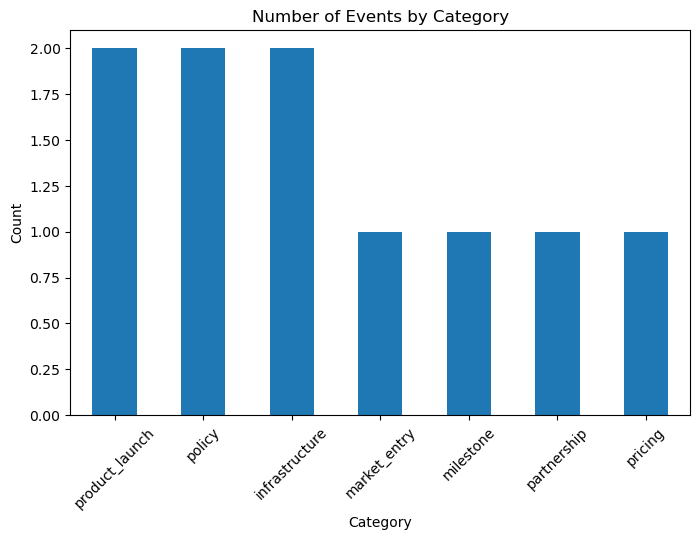

In [27]:
plt.figure(figsize=(8,5))

events_df["category"].value_counts().plot(
    kind="bar"
)

plt.title("Number of Events by Category")

plt.xlabel("Category")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

## Impact Link Exploration

This section investigates how events are connected to financial inclusion indicators. These relationships will later be used to model the effect of events on financial inclusion outcomes.

In [28]:
impact_df.head()

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,...,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,...,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices


In [29]:
impact_df["relationship_type"].value_counts()

relationship_type
direct      9
indirect    4
enabling    1
Name: count, dtype: int64

In [30]:
impact_df["impact_direction"].value_counts()

impact_direction
increase    12
decrease     2
Name: count, dtype: int64

In [31]:
impact_df["impact_magnitude"].value_counts()

impact_magnitude
medium    8
high      5
low       1
Name: count, dtype: int64

In [32]:
impact_df["evidence_basis"].value_counts()

evidence_basis
literature     7
empirical      6
theoretical    1
Name: count, dtype: int64

### Merging Data

In [34]:
event_impacts = impact_df.merge(
    df[
        [
            "record_id",
            "indicator",
            "category",
            "observation_date"
        ]
    ],
    left_on="parent_id",
    right_on="record_id",
    how="left",
    suffixes=("_impact", "_event")
)

event_impacts.head()

,record_id_impact,parent_id,record_type,category_impact,pillar,indicator_impact,indicator_code,indicator_direction,value_numeric,value_text,...,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,record_id_event,indicator_event,category_event,observation_date_event
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years,EVT_0001,Telebirr Launch,product_launch,2021-05-17
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition,EVT_0001,Telebirr Launch,product_launch,2021-05-17
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel,EVT_0001,Telebirr Launch,product_launch,2021-05-17
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,...,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,...,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01


In [36]:
event_impacts.columns

Index(['record_id_impact', 'parent_id', 'record_type', 'category_impact',
       'pillar', 'indicator_impact', 'indicator_code', 'indicator_direction',
       'value_numeric', 'value_text', 'value_type', 'unit',
       'observation_date_impact', 'period_start', 'period_end', 'fiscal_year',
       'gender', 'location', 'region', 'source_name', 'source_type',
       'source_url', 'confidence', 'related_indicator', 'relationship_type',
       'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months',
       'evidence_basis', 'comparable_country', 'collected_by',
       'collection_date', 'original_text', 'notes', 'record_id_event',
       'indicator_event', 'category_event', 'observation_date_event'],
      dtype='object')

In [38]:
impact_summary = event_impacts[
    [
        "indicator_event",
        "indicator_impact",
        "pillar",
        "impact_direction",
        "impact_magnitude",
        "lag_months",
        "evidence_basis"
    ]
]

impact_summary

,indicator_event,indicator_impact,pillar,impact_direction,impact_magnitude,lag_months,evidence_basis
0,Telebirr Launch,Telebirr effect on Account Ownership,ACCESS,increase,high,12,literature
1,Telebirr Launch,Telebirr effect on Telebirr Users,USAGE,increase,high,3,empirical
2,Telebirr Launch,Telebirr effect on P2P Transactions,USAGE,increase,high,6,empirical
3,Safaricom Ethiopia Commercial Launch,Safaricom effect on 4G Coverage,ACCESS,increase,medium,12,empirical
4,Safaricom Ethiopia Commercial Launch,Safaricom effect on Data Affordability,AFFORDABILITY,decrease,medium,12,literature
5,M-Pesa Ethiopia Launch,M-Pesa effect on M-Pesa Users,USAGE,increase,high,3,empirical
6,M-Pesa Ethiopia Launch,M-Pesa effect on Mobile Money Account Rate,ACCESS,increase,medium,6,theoretical
7,Fayda Digital ID Program Rollout,Fayda effect on Account Ownership,ACCESS,increase,medium,24,literature
8,Fayda Digital ID Program Rollout,Fayda effect on Gender Gap,GENDER,decrease,medium,24,literature
9,Foreign Exchange Liberalization,FX Reform effect on Data Affordability,AFFORDABILITY,increase,high,3,empirical


In [39]:
impact_matrix = impact_summary.pivot_table(
    index="indicator_event",
    columns="pillar",
    values="lag_months",
    aggfunc="mean"
)

impact_matrix

pillar,ACCESS,AFFORDABILITY,GENDER,USAGE
indicator_event,,,,
EthioPay Instant Payment System Launch,NaN,NaN,NaN,6.0
Fayda Digital ID Program Rollout,24.0,NaN,24.0,NaN
Foreign Exchange Liberalization,NaN,3.0,NaN,NaN
M-Pesa EthSwitch Integration,NaN,NaN,NaN,3.0
M-Pesa Ethiopia Launch,6.0,NaN,NaN,3.0
Safaricom Ethiopia Commercial Launch,12.0,12.0,NaN,NaN
Safaricom Ethiopia Price Increase,NaN,1.0,NaN,NaN
Telebirr Launch,12.0,NaN,NaN,4.5


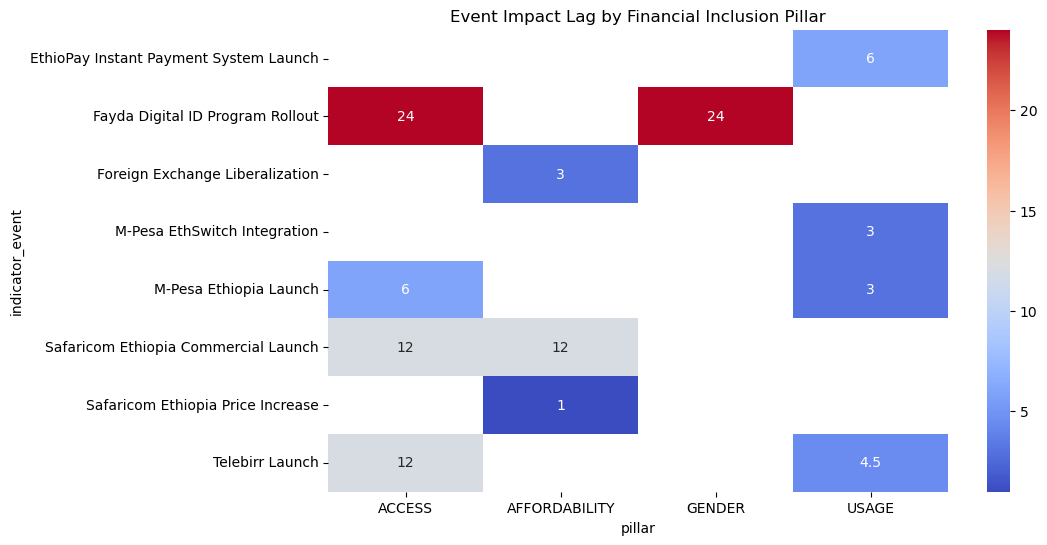

In [40]:
plt.figure(figsize=(10,6))

sns.heatmap(
    impact_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Event Impact Lag by Financial Inclusion Pillar"
)

plt.show()

In [41]:
df.columns.tolist()

['record_id',
 'record_type',
 'category',
 'pillar',
 'indicator',
 'indicator_code',
 'indicator_direction',
 'value_numeric',
 'value_text',
 'value_type',
 'unit',
 'observation_date',
 'period_start',
 'period_end',
 'fiscal_year',
 'gender',
 'location',
 'region',
 'source_name',
 'source_type',
 'source_url',
 'confidence',
 'related_indicator',
 'relationship_type',
 'impact_direction',
 'impact_magnitude',
 'impact_estimate',
 'lag_months',
 'evidence_basis',
 'comparable_country',
 'collected_by',
 'collection_date',
 'original_text',
 'notes']